In [5]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import logging
import os

from scipy.stats import pearsonr

In [6]:
logging.basicConfig(
    filename="rossmann_eda.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger()

logger.info("Rossmann EDA project started")

print("Logging setup completed.")

Logging setup completed.


In [7]:
# set basic style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Load the data
store = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/project6/store.csv")
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/project6/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/project6/test.csv")

logger.info("Store, train and test datasets loaded successfully")

/tmp/ipykernel_1280/2631994474.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/project6/train.csv")


In [10]:
print("Store:", store.shape)
print("Train:", train.shape)
print("Test:", test.shape)

Store: (1115, 10)
Train: (1017209, 9)
Test: (41088, 8)


In [11]:
# columns details
print(store.columns)
print(train.columns)
print(test.columns)

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')
Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')
Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='object')


In [12]:
# Merge store with train
train_merged = train.merge(
    store,
    on="Store",
    how="left"
)
# Merge store with test
test_merged = test.merge(
    store,
    on="Store",
    how="left"
)
logger.info("Store data merged with train and test")

In [13]:
# check the result
print("Train merged:", train_merged.shape)
print("Test merged:", test_merged.shape)

Train merged: (1017209, 18)
Test merged: (41088, 17)


In [14]:
# statical summery
train_merged.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [15]:
test_merged.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000,40992.000000,25872.000000,25872.000000,41088.000000,23856.000000,23856.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487,5088.583138,7.035250,2008.641929,0.580607,24.426559,2011.820926
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802,7225.487467,3.143015,6.862400,0.493466,14.161312,1.692166
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000,720.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000,2425.000000,7.000000,2010.000000,1.000000,22.000000,2012.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000,6480.000000,9.000000,2012.000000,1.000000,37.000000,2013.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,49.000000,2015.000000


In [16]:
# dataset information:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [17]:
test_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  object 
 4   Open                       41077 non-null  float64
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  object 
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  object 
 9   Assortment                 41088 non-null  object 
 10  CompetitionDistance        40992 non-null  float64
 11  CompetitionOpenSinceMonth  25872 non-null  float64
 12  CompetitionOpenSinceYear   25872 non-null  float64
 13  Promo2                     41088 non-null  int

In [18]:
# check unique values
print("StoreType:")
print(train_merged["StoreType"].unique())

print("\nAssortment:")
print(train_merged["Assortment"].unique())

print("\nPromo:")
print(train_merged["Promo"].unique())

print("\nPromo2:")
print(train_merged["Promo2"].unique())

print("\nStateHoliday:")
print(train_merged["StateHoliday"].unique())

StoreType:
['c' 'a' 'd' 'b']

Assortment:
['a' 'c' 'b']

Promo:
[1 0]

Promo2:
[0 1]

StateHoliday:
['0' 'a' 'b' 'c' 0]


In [19]:
# check data types
train_merged.dtypes

,0
Store,int64
DayOfWeek,int64
Date,object
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object


In [20]:
logger.info("Initial data understanding completed")

In [21]:
#  Missing values
print(train_merged.isnull().sum())
print(test_merged.isnull().sum())

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64
Id                               0
Store                            0
DayOfWeek                        0
Date                             0
Open                            11
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment              

In [22]:
train_merged.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [23]:
test_merged.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [24]:
# drop ID column
test_merged.drop("Id", axis=1, inplace=True)

In [25]:
test_merged.shape

(41088, 16)

In [26]:
# Fill missing values

# distance columns
median_distance = train_merged["CompetitionDistance"].median()
train_merged["CompetitionDistance"].fillna(median_distance, inplace=True)
test_merged["CompetitionDistance"].fillna(median_distance, inplace=True)

/tmp/ipykernel_1280/1005782311.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_merged["CompetitionDistance"].fillna(median_distance, inplace=True)
/tmp/ipykernel_1280/1005782311.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [27]:
# compition columns
competition_cols = ["CompetitionOpenSinceMonth","CompetitionOpenSinceYear","Promo2SinceWeek","Promo2SinceYear"]
for col in competition_cols:
    train_merged[col].fillna(0, inplace=True)
    test_merged[col].fillna(0, inplace=True)

/tmp/ipykernel_1280/1203570066.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_merged[col].fillna(0, inplace=True)
/tmp/ipykernel_1280/1203570066.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [28]:
# promo columns
train_merged["Promo2"].value_counts()

,count
Promo2,
1,509178
0,508031


In [29]:
promo_numeric_cols = [
    "Promo2SinceWeek",
    "Promo2SinceYear"
]

for col in promo_numeric_cols:
    train_merged[col] = train_merged[col].fillna(0)
    test_merged[col] = test_merged[col].fillna(0)

In [30]:
train_merged["PromoInterval"] = train_merged["PromoInterval"].fillna("None")
test_merged["PromoInterval"] = test_merged["PromoInterval"].fillna("None")

In [31]:
# open mode
open_mode = train_merged["Open"].mode()[0]

test_merged["Open"] = (
    test_merged["Open"].fillna(open_mode)
)

In [32]:
print(train_merged.isnull().sum(),"\n")
print(test_merged.isnull().sum())

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64 

Store                        0
DayOfWeek                    0
Date                         0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek         

In [33]:
logger.info("Missing value treatment completed")

In [34]:
# find the duplicates
print(
    "Train duplicates:",
    train_merged.duplicated().sum()
)

print(
    "Test duplicates:",
    test_merged.duplicated().sum()
)

Train duplicates: 0
Test duplicates: 0


In [35]:
logger.info("Duplicate records checked")

In [36]:
# Outlier Detection

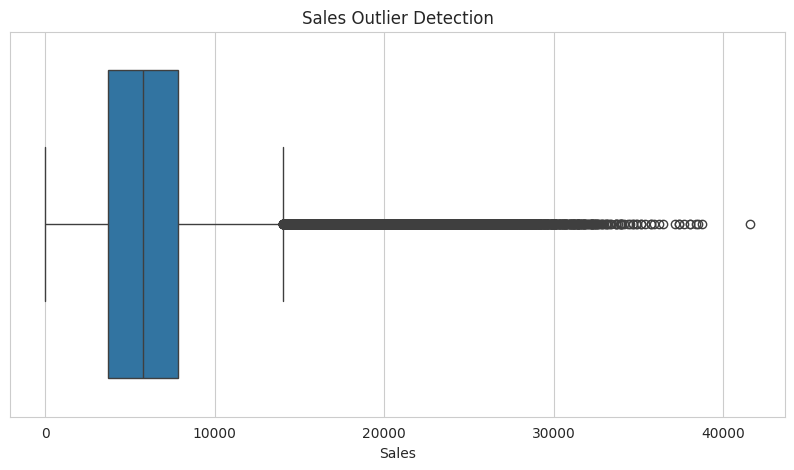

In [37]:
# Sales Boxplot

plt.figure(figsize=(10,5))

sns.boxplot(x=train_merged["Sales"])

plt.title("Sales Outlier Detection")
plt.xlabel("Sales")

plt.show()

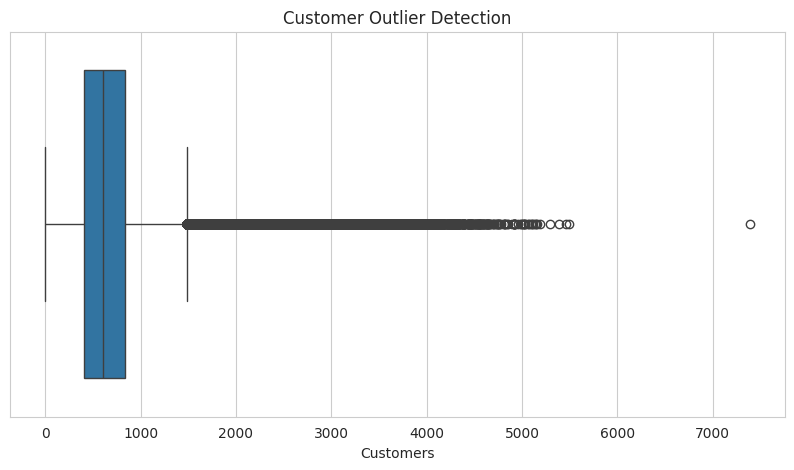

In [38]:
# Customer Boxplot
plt.figure(figsize=(10,5))

sns.boxplot(x=train_merged["Customers"])

plt.title("Customer Outlier Detection")
plt.xlabel("Customers")

plt.show()

In [39]:
# IQR Method

def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


In [40]:
sales_outliers, lower, upper = detect_outliers_iqr(
    train_merged,
    "Sales"
)

print("Sales Outliers:", len(sales_outliers))

Sales Outliers: 26694


In [41]:
customer_outliers, lower, upper = detect_outliers_iqr(
    train_merged,
    "Customers"
)

print("Customer Outliers:", len(customer_outliers))

Customer Outliers: 38095


In [42]:
logger.info("Outlier detection completed using IQR method")

In [43]:
# Data Types
train_merged.dtypes


,0
Store,int64
DayOfWeek,int64
Date,object
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object


In [44]:
train_merged["Date"] = pd.to_datetime(
    train_merged["Date"]
)

test_merged["Date"] = pd.to_datetime(
    test_merged["Date"]
)
print(train_merged["Date"].dtype)

datetime64[ns]


In [45]:
logger.info("Data types checked and Date converted to datetime")

**Feature Engineering**

In [46]:
# Year
for df in [train_merged, test_merged]:
    df["Year"] = df["Date"].dt.year

In [47]:
# Month
for df in [train_merged, test_merged]:
    df["Month"] = df["Date"].dt.month

In [48]:
# Day
for df in [train_merged, test_merged]:
    df["Day"] = df["Date"].dt.day

In [49]:
# Week of the year
for df in [train_merged, test_merged]:
    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

In [50]:
# weekend
for df in [train_merged, test_merged]:
    df["IsWeekend"] = (
        df["Date"].dt.dayofweek >= 5
    ).astype(int)

In [51]:
# quarter
for df in [train_merged, test_merged]:
    df["Quarter"] = df["Date"].dt.quarter

In [52]:
# Holiday indicator
for df in [train_merged, test_merged]:
    df["IsHoliday"] = (
        df["StateHoliday"] != "0"
    ).astype(int)

In [53]:
train_merged[
    ["Date", "Year", "Month", "Day",
     "WeekOfYear", "IsWeekend", "Quarter", "IsHoliday"]
].head(10)

,Date,Year,Month,Day,WeekOfYear,IsWeekend,Quarter,IsHoliday
0,2015-07-31,2015,7,31,31,0,3,0
1,2015-07-31,2015,7,31,31,0,3,0
2,2015-07-31,2015,7,31,31,0,3,0
3,2015-07-31,2015,7,31,31,0,3,0
4,2015-07-31,2015,7,31,31,0,3,0
5,2015-07-31,2015,7,31,31,0,3,0
6,2015-07-31,2015,7,31,31,0,3,0
7,2015-07-31,2015,7,31,31,0,3,0
8,2015-07-31,2015,7,31,31,0,3,0
9,2015-07-31,2015,7,31,31,0,3,0


In [54]:
logger.info("Feature engineering completed")

In [93]:
# Save clean data

train_merged.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/project6/train_cleaned.csv",
    index=False
)

test_merged.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/project6/test_cleaned.csv",
    index=False
)

In [ ]:
logger.info("Cleaned train dataset saved")
logger.info("Cleaned test dataset saved")

Exploratory Data Analysis

In [55]:
# Train vs Test Distribution

# Promo distribution
train_promo = (
    train_merged["Promo"]
    .value_counts(normalize=True) * 100
)

test_promo = (
    test_merged["Promo"]
    .value_counts(normalize=True) * 100
)

promo_comparison = pd.DataFrame({
    "Train": train_promo,
    "Test": test_promo
})

promo_comparison

,Train,Test
Promo,,
0,61.848548,60.416667
1,38.151452,39.583333


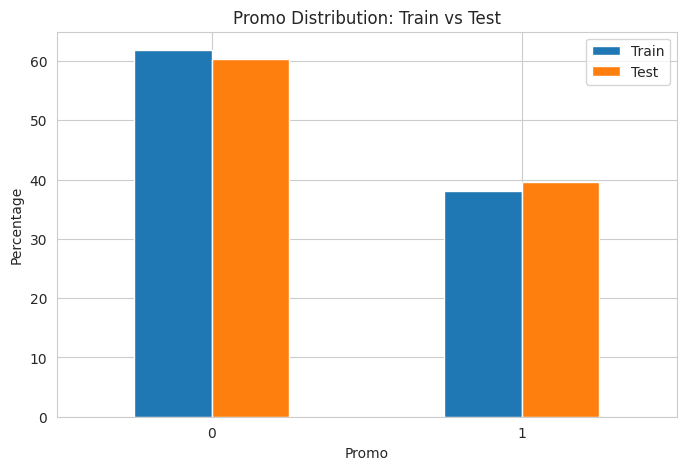

In [56]:
promo_comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Promo Distribution: Train vs Test")
plt.xlabel("Promo")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

**Insight**

The distribution of promotional and non-promotional observations is compared between the training and test datasets. A similar distribution indicates that the test set follows a comparable promotional pattern to the training data.

In [57]:
# Holiday Analysis

# Average sales by StateHoliday
holiday_sales = (
    train_merged.groupby("StateHoliday")["Sales"]
    .mean()
)

holiday_sales

,Sales
StateHoliday,
0,5733.530624
0,5980.279717
a,290.735686
b,214.311510
c,168.733171


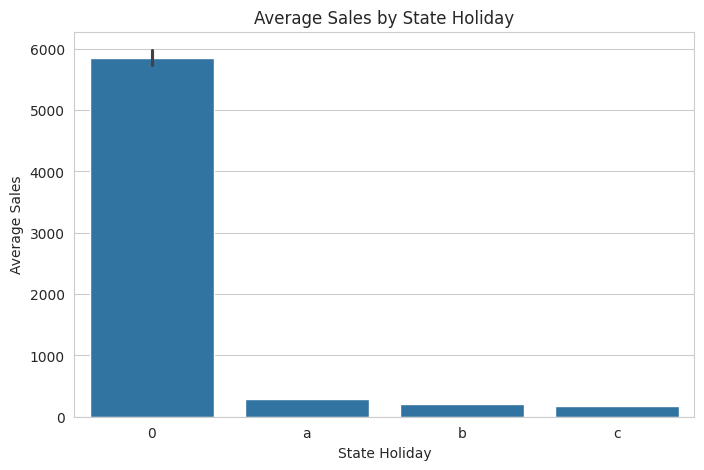

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.title("Average Sales by State Holiday")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")

plt.show()

In [59]:
# School Holiday
school_holiday_sales = (
    train_merged.groupby("SchoolHoliday")["Sales"]
    .mean()
)

school_holiday_sales

,Sales
SchoolHoliday,
0,5620.979034
1,6476.522207


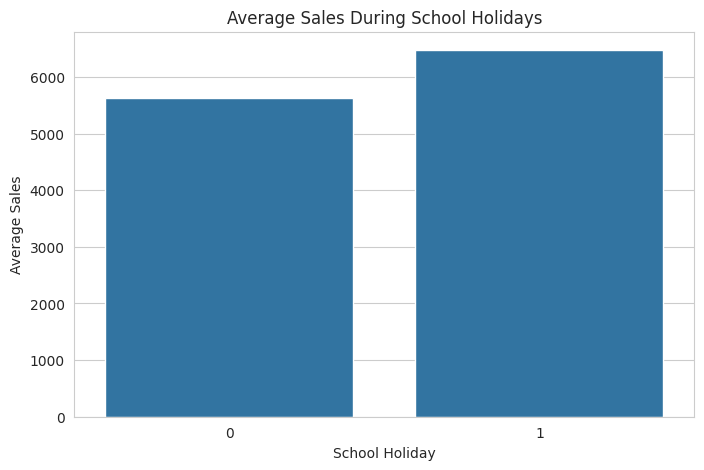

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=school_holiday_sales.index,
    y=school_holiday_sales.values
)

plt.title("Average Sales During School Holidays")
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")

plt.show()

In [61]:
# Seasonal Analysis

# Monthly sales
monthly_sales = (
    train_merged
    .groupby("Month")["Sales"]
    .mean()
)
monthly_sales

,Sales
Month,
1,5465.395529
2,5645.253150
3,5784.578871
4,5738.866916
5,5489.639973
6,5760.964375
7,6064.915711
8,5693.016554
9,5570.246033


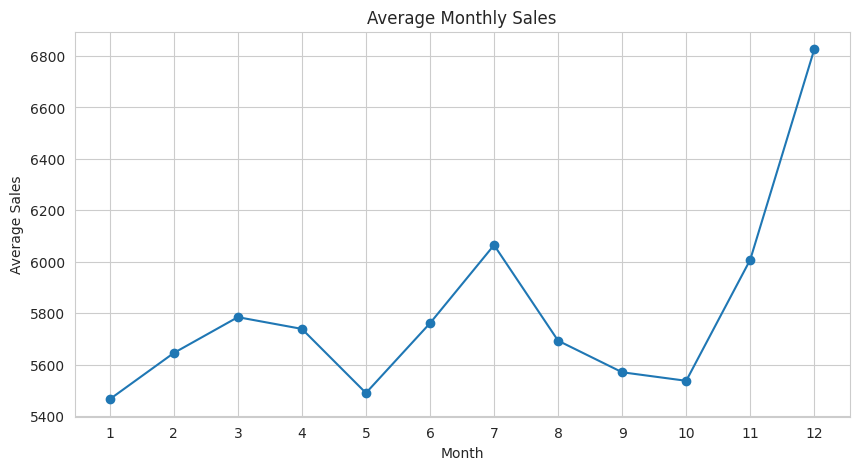

In [62]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1,13))

plt.show()

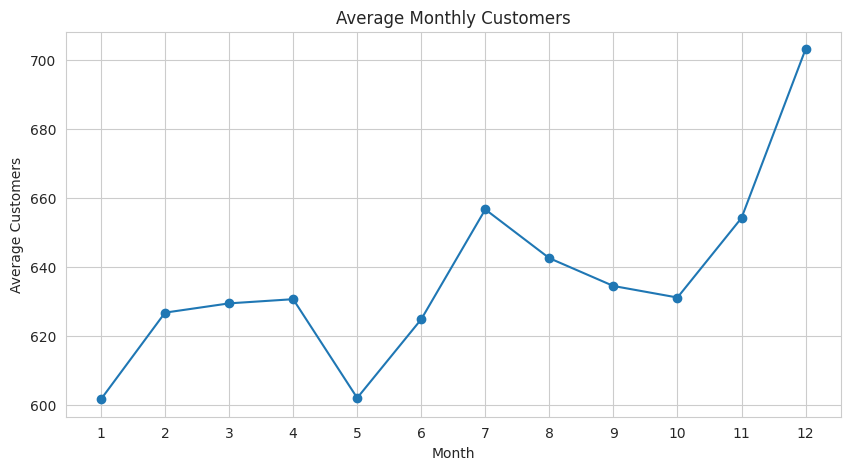

In [63]:
# Monthly customers

monthly_customers = (
    train_merged
    .groupby("Month")["Customers"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_customers.index,
    monthly_customers.values,
    marker="o"
)

plt.title("Average Monthly Customers")
plt.xlabel("Month")
plt.ylabel("Average Customers")

plt.xticks(range(1,13))

plt.show()

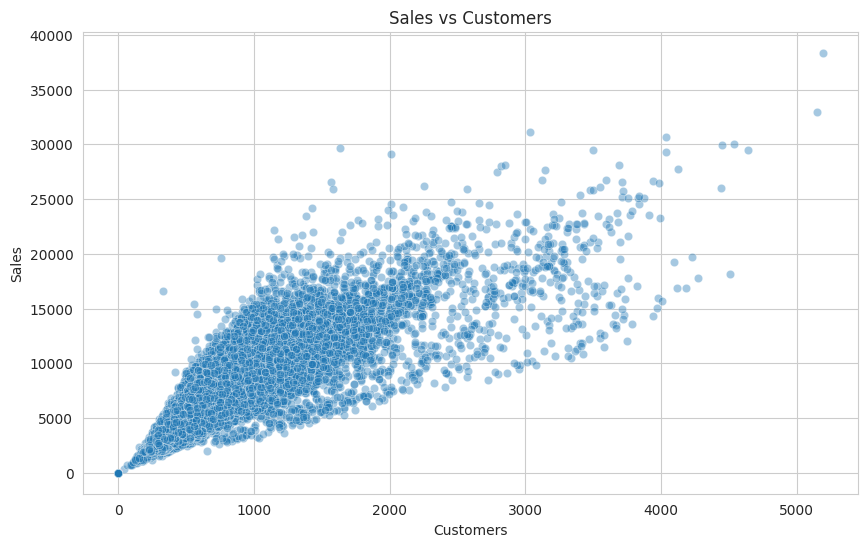

In [64]:
# Sales vs Customers

sample_data = train_merged.sample(
    min(50000, len(train_merged)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_data,
    x="Customers",
    y="Sales",
    alpha=0.4
)

plt.title("Sales vs Customers")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

In [65]:
correlation = train_merged[
    ["Sales", "Customers"]
].corr()

correlation

,Sales,Customers
Sales,1.000000,0.894711
Customers,0.894711,1.000000


In [66]:
print(
    "Correlation between Sales and Customers:",
    train_merged["Sales"].corr(
        train_merged["Customers"]
    )
)

Correlation between Sales and Customers: 0.8947107733017032


**Insight**

If correlation is strongly positive:

Sales and customer count show a strong positive relationship, indicating that stores with higher customer traffic generally generate higher sales.

In [67]:
# Promo Analysis

# Promo vs Sales

promo_sales = (
    train_merged
    .groupby("Promo")["Sales"]
    .mean()
)

promo_sales

,Sales
Promo,
0,4406.050805
1,7991.152046


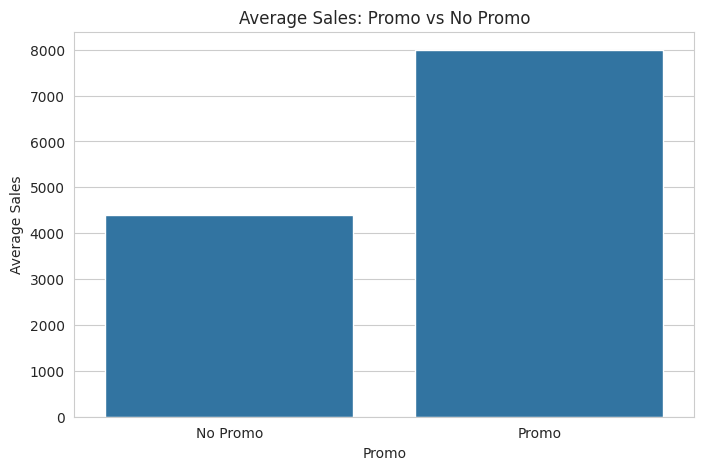

In [68]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=promo_sales.index,
    y=promo_sales.values
)

plt.title("Average Sales: Promo vs No Promo")
plt.xlabel("Promo")
plt.ylabel("Average Sales")
plt.xticks([0,1], ["No Promo", "Promo"])

plt.show()

In [69]:
# Promo Effectiveness
# Compare Sales + Customers

promo_summary = (
    train_merged
    .groupby("Promo")
    .agg(
        Average_Sales=("Sales", "mean"),
        Average_Customers=("Customers", "mean")
    )
)

promo_summary


,Average_Sales,Average_Customers
Promo,,
0,4406.050805,517.823542
1,7991.152046,820.098815


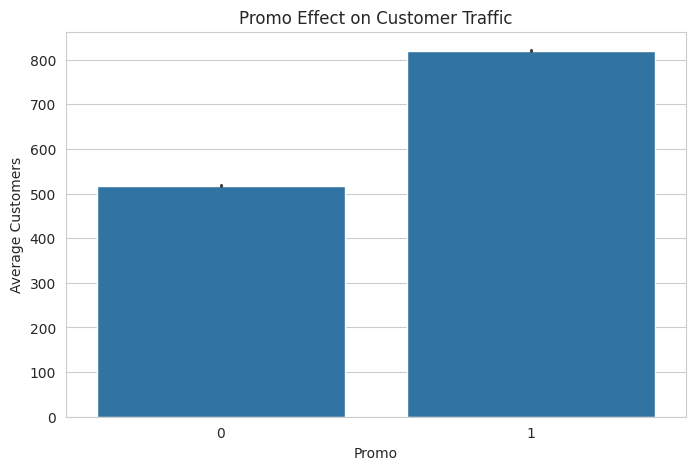

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train_merged,
    x="Promo",
    y="Customers"
)

plt.title("Promo Effect on Customer Traffic")
plt.xlabel("Promo")
plt.ylabel("Average Customers")

plt.show()

In [74]:
# Store-level promotion effectiveness

store_promo = (
    train_merged
    .groupby(["Store", "Promo"])
    .agg(
        AvgSales=("Sales", "mean"),
        AvgCustomers=("Customers", "mean")
    )
    .reset_index()
)

store_pivot = store_promo.pivot(
    index="Store",
    columns="Promo",
    values="AvgSales"
)

store_pivot.columns = [
    "No_Promo_Sales",
    "Promo_Sales"
]

# Calculate uplift
store_pivot["Promo_Uplift"] = (
    store_pivot["Promo_Sales"] - store_pivot["No_Promo_Sales"]
)
store_pivot["Promo_Uplift_%"] = (
    (store_pivot["Promo_Uplift"] / store_pivot["No_Promo_Sales"]) * 100
)

# Top Stores
store_pivot.sort_values(
    "Promo_Uplift_%",
    ascending=False
).head(10)

,No_Promo_Sales,Promo_Sales,Promo_Uplift,Promo_Uplift_%
Store,,,,
198,1292.500000,4211.216667,2918.716667,225.819471
607,1880.798969,5435.191667,3554.392698,188.983127
543,1383.443299,3817.008333,2433.565034,175.906381
575,2664.858051,7294.339161,4629.481110,173.723366
271,4009.890034,10507.675000,6497.784966,162.043969
693,3390.144330,8854.822222,5464.677892,161.193075
96,2675.621993,6891.002778,4215.380785,157.547695
1108,2976.214777,7640.116667,4663.901890,156.705824
552,4008.190722,10272.252778,6264.062056,156.281537


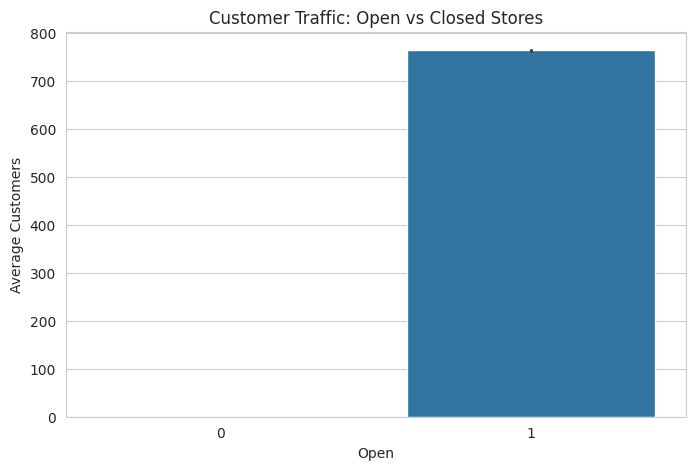

In [75]:
# Store opening and closing

train_merged.groupby("Open")[
    ["Sales", "Customers"]
].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=train_merged,
    x="Open",
    y="Customers"
)

plt.title("Customer Traffic: Open vs Closed Stores")
plt.xlabel("Open")
plt.ylabel("Average Customers")

plt.show()

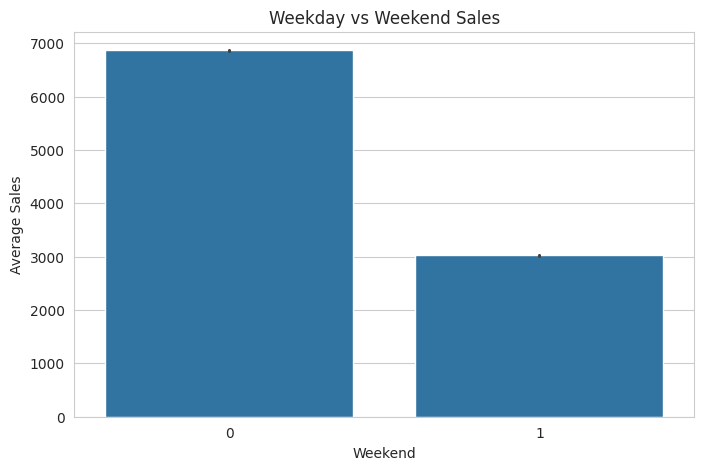

In [76]:
# Weekday vs Weekend

train_merged.groupby("IsWeekend")[
    ["Sales", "Customers"]
].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=train_merged,
    x="IsWeekend",
    y="Sales"
)

plt.title("Weekday vs Weekend Sales")
plt.xlabel("Weekend")
plt.ylabel("Average Sales")

plt.show()

In [77]:
# Assortment Analysis

assortment_summary = (
    train_merged
    .groupby("Assortment")
    .agg(
        Average_Sales=("Sales", "mean"),
        Average_Customers=("Customers", "mean"),
        Store_Count=("Store", "nunique")
    )
)

assortment_summary

,Average_Sales,Average_Customers,Store_Count
Assortment,,,
a,5481.026096,619.164636,593
b,8553.931999,2046.361828,9
c,6058.676567,624.222733,513


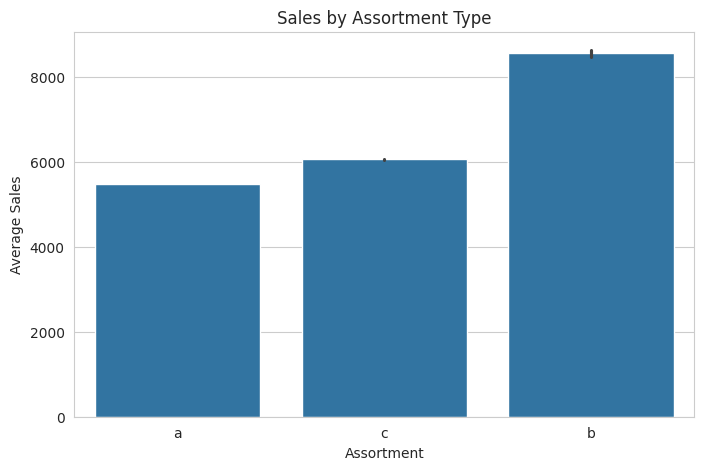

In [78]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train_merged,
    x="Assortment",
    y="Sales"
)

plt.title("Sales by Assortment Type")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")

plt.show()

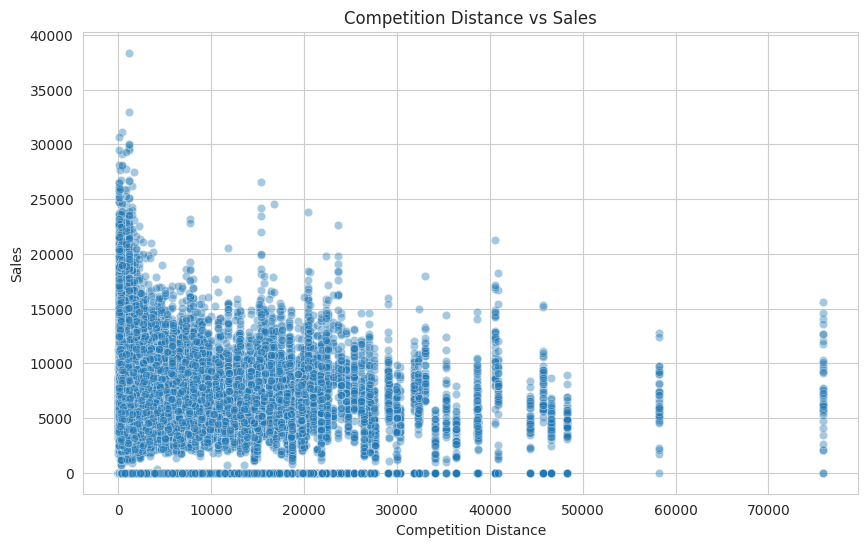

In [79]:
# Competition Distance

sample_data = train_merged.sample(
    min(50000, len(train_merged)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_data,
    x="CompetitionDistance",
    y="Sales",
    alpha=0.4
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")

plt.show()

In [80]:
train_merged[
    ["CompetitionDistance", "Sales"]
].corr()

,CompetitionDistance,Sales
CompetitionDistance,1.00000,-0.01887
Sales,-0.01887,1.00000


In [84]:
# Competition distance bands

train_merged["CompetitionDistanceBand"] = pd.cut(
    train_merged["CompetitionDistance"],
    bins=[
        0,
        500,
        1000,
        2000,
        5000,
        10000,
        np.inf
    ],
    labels=[
        "<500m",
        "500m-1km",
        "1-2km",
        "2-5km",
        "5-10km",
        ">10km"
    ]
)

distance_sales = (
    train_merged
    .groupby(
        "CompetitionDistanceBand",
        observed=True
    )["Sales"]
    .mean()
)

distance_sales

,Sales
CompetitionDistanceBand,
<500m,6307.393560
500m-1km,5565.373637
1-2km,5897.762499
2-5km,5518.953163
5-10km,5567.718124
>10km,5685.546657


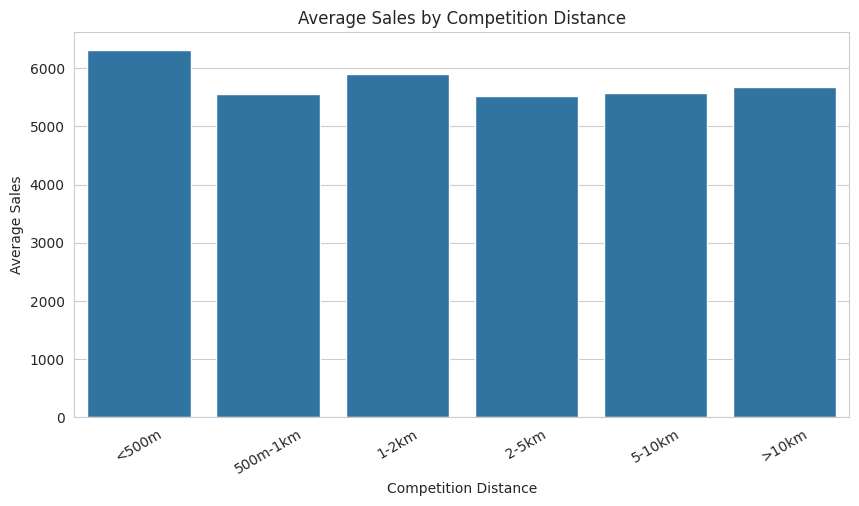

In [85]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=distance_sales.index,
    y=distance_sales.values
)

plt.title("Average Sales by Competition Distance")
plt.xlabel("Competition Distance")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.show()

In [86]:
# New Competitors

train_merged["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=train_merged[
            "CompetitionOpenSinceYear"
        ].replace(0, np.nan),

        month=train_merged[
            "CompetitionOpenSinceMonth"
        ].replace(0, np.nan),

        day=1
    ),
    errors="coerce"
)

In [87]:
train_merged["MonthsSinceCompetition"] = (
    (
        train_merged["Date"].dt.year
        -
        train_merged["CompetitionOpenDate"].dt.year
    ) * 12
    +
    (
        train_merged["Date"].dt.month
        -
        train_merged["CompetitionOpenDate"].dt.month
    )
)

In [89]:
train_merged["CompetitionPeriod"] = pd.cut(
    train_merged["MonthsSinceCompetition"],
    bins=[
        -np.inf,
        -12,
        -6,
        0,
        6,
        12,
        24,
        np.inf
    ],
    labels=[
        "< -12 months",
        "-12 to -6 months",
        "-6 to 0 months",
        "0 to 6 months",
        "6 to 12 months",
        "12 to 24 months",
        ">24 months"
    ]
)

competition_effect = (
    train_merged
    .groupby(
        "CompetitionPeriod",
        observed=True
    )["Sales"]
    .mean()
)

competition_effect

,Sales
CompetitionPeriod,
< -12 months,5714.566523
-12 to -6 months,6027.755644
-6 to 0 months,6246.011071
0 to 6 months,5869.546967
6 to 12 months,5961.103267
12 to 24 months,5951.979245
>24 months,5695.017506


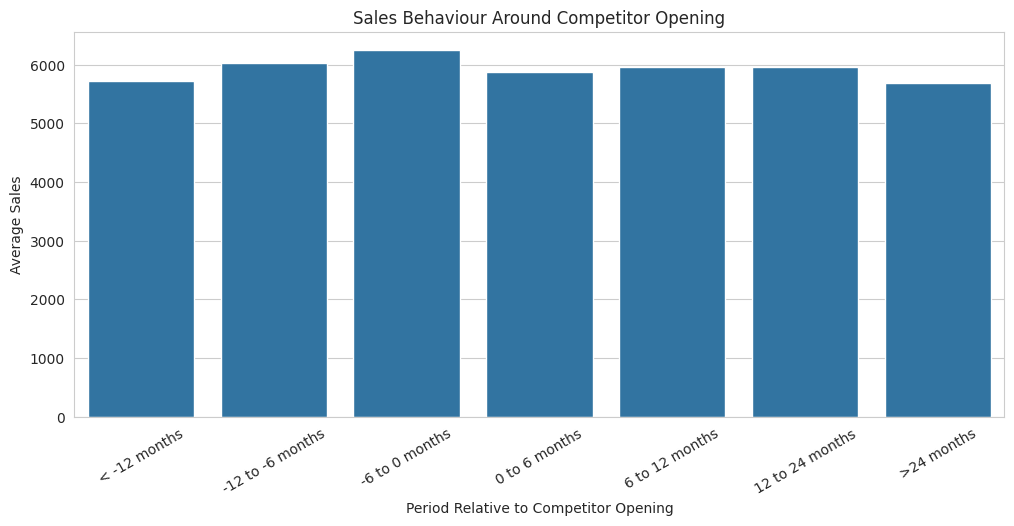

In [90]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=competition_effect.index,
    y=competition_effect.values
)

plt.title("Sales Behaviour Around Competitor Opening")
plt.xlabel("Period Relative to Competitor Opening")
plt.ylabel("Average Sales")

plt.xticks(rotation=30)

plt.show()

Business Insight

Customer Behaviour

Customer count has a strong positive relationship with sales. Therefore, customer traffic can be used as an important indicator of store sales performance.

Promotions

Promotional periods should be evaluated using both sales and customer traffic. Stores showing high promotional uplift can be prioritized for targeted campaigns.

Seasonality

Sales vary across months, indicating seasonal purchasing behaviour. Promotional and inventory strategies should therefore account for seasonal demand.

Competition

Competition distance shows differences in sales behaviour across stores. However, competitor distance alone may not explain store performance because location, store type and customer traffic also influence sales.

Assortment

Different assortment types demonstrate different average sales and customer traffic, suggesting that assortment strategy can influence store performance.

# Conclusion

The exploratory analysis provided insights into customer purchasing behaviour across Rossmann stores.

Key findings include:

1. Customer traffic has a strong relationship with sales.
2. Promotional campaigns influence both sales and customer traffic.
3. Sales demonstrate seasonal and holiday-related variations.
4. Store characteristics such as assortment and store type contribute to differences in sales performance.
5. Competition distance and competitor openings can influence store performance.
6. Promotional strategies should be targeted toward stores where historical promotions generate higher sales or customer uplift.
7. Store-level analysis is more useful than applying the same strategy to every store.

In [91]:
logger.info("Business insights documented")
logger.info("Rossmann EDA project completed successfully")

print("EDA completed successfully.")

EDA completed successfully.
